## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

---

# PRÁCTICA No. 26: CNN(FER-2013)

### La CNN se implementará para predecir emociones faciales de la base de datos FER-2013 (Facial Expression Recognition)
### La base de datos FER-2013 es un conjunto de datos ampliamente utilizado en el reconocimiento de emociones faciales. Contiene imágenes de rostros humanos expresando diferentes emociones, con las siguientes características: 35,887 imágenes en total distribuidas en entrenamiento y prueba, imágenes en escala de grises de 48x48 píxeles, y etiquetadas con una de las 7 emociones: angry (enojo), disgust (asco), fear (miedo), happy (felicidad), sad (tristeza), surprise (sorpresa) y neutral (neutral)




## Paso 1: Importar las librerías necesarias

In [14]:
import os 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from PIL import Image

## Paso 2: Cargar el dataset FER-2013

### El dataset está organizado en carpetas /train y /test, donde cada subcarpeta representa una emoción

In [15]:
# Definir las rutas de los directorios
train_dir = './train'
test_dir = './test'

# Definir las clases de emociones
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
num_classes = len(emotion_labels)

print(f"Número de clases: {num_classes}")
print(f"Emociones: {emotion_labels}")

Número de clases: 7
Emociones: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']


## Paso 3: Función para cargar imágenes desde carpetas

In [16]:
def load_images_from_folder(base_path, img_size=(48, 48)):
    """
    Carga imágenes desde una estructura de carpetas donde cada subcarpeta es una clase
    """
    images = []
    labels = []
    
    for label_idx, emotion in enumerate(emotion_labels):
        emotion_path = os.path.join(base_path, emotion)
        
        if not os.path.exists(emotion_path):
            print(f"Advertencia: No se encontró la carpeta {emotion_path}")
            continue
        
        # Contar archivos en la carpeta
        files = [f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        print(f"Cargando {len(files)} imágenes de {emotion}...")
        
        for img_file in files:
            img_path = os.path.join(emotion_path, img_file)
            try:
                # Cargar imagen en escala de grises
                img = Image.open(img_path).convert('L')
                # Redimensionar a 48x48 si es necesario
                img = img.resize(img_size)
                # Convertir a array numpy
                img_array = np.array(img)
                images.append(img_array)
                labels.append(label_idx)
            except Exception as e:
                print(f"Error cargando {img_path}: {e}")
    
    return np.array(images), np.array(labels)

# Cargar datos de entrenamiento y prueba
print("Cargando datos de entrenamiento...")
X_train, y_train = load_images_from_folder(train_dir)

print("\nCargando datos de prueba...")
X_test, y_test = load_images_from_folder(test_dir)

print(f"\nForma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")

Cargando datos de entrenamiento...
Cargando 3995 imágenes de angry...
Cargando 436 imágenes de disgust...
Cargando 4097 imágenes de fear...
Cargando 7215 imágenes de happy...
Cargando 4830 imágenes de sad...
Cargando 3171 imágenes de surprise...
Cargando 4965 imágenes de neutral...

Cargando datos de prueba...
Cargando 958 imágenes de angry...
Cargando 111 imágenes de disgust...
Cargando 1024 imágenes de fear...
Cargando 1774 imágenes de happy...
Cargando 1247 imágenes de sad...
Cargando 831 imágenes de surprise...
Cargando 1233 imágenes de neutral...

Forma de X_train: (28709, 48, 48)
Forma de y_train: (28709,)
Forma de X_test: (7178, 48, 48)
Forma de y_test: (7178,)


## Paso 4: Explorar los datos

Distribución de clases en entrenamiento:
angry: 3995 imágenes
disgust: 436 imágenes
fear: 4097 imágenes
happy: 7215 imágenes
sad: 4830 imágenes
surprise: 3171 imágenes
neutral: 4965 imágenes

Distribución de clases en prueba:
angry: 958 imágenes
disgust: 111 imágenes
fear: 1024 imágenes
happy: 1774 imágenes
sad: 1247 imágenes
surprise: 831 imágenes
neutral: 1233 imágenes


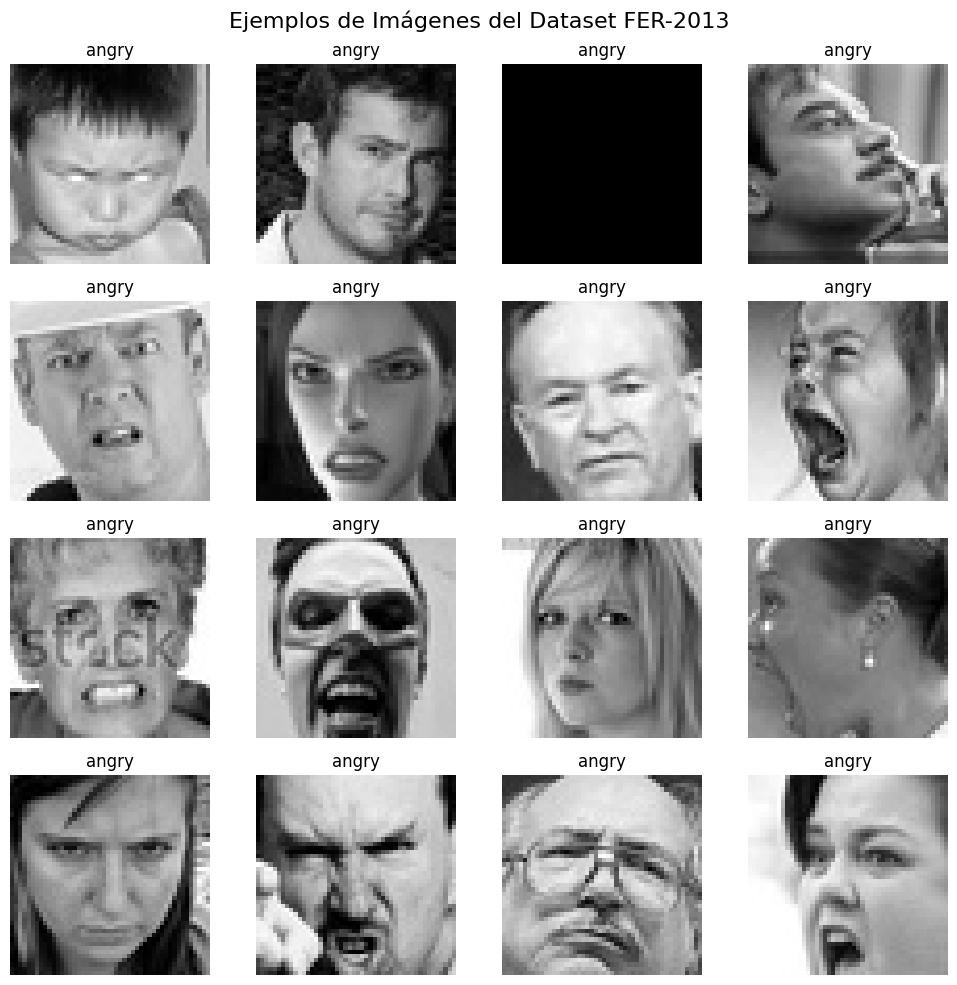

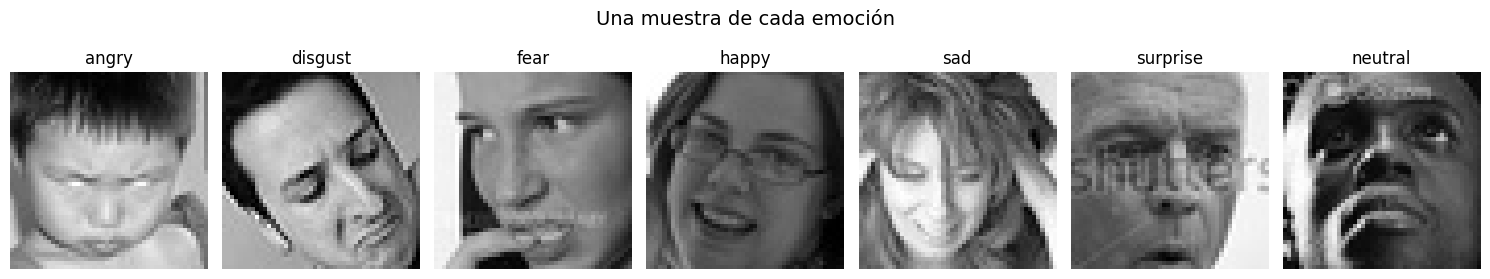

In [17]:
# Mostrar ejemplos de cada emoción
print("Distribución de clases en entrenamiento:")
unique, counts = np.unique(y_train, return_counts=True)
for emotion_idx, count in zip(unique, counts):
    print(f"{emotion_labels[emotion_idx]}: {count} imágenes")

print("\nDistribución de clases en prueba:")
unique, counts = np.unique(y_test, return_counts=True)
for emotion_idx, count in zip(unique, counts):
    print(f"{emotion_labels[emotion_idx]}: {count} imágenes")

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Ejemplos de Imágenes del Dataset FER-2013', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < len(X_train):
        ax.imshow(X_train[i], cmap='gray')
        ax.set_title(f'{emotion_labels[y_train[i]]}')
        ax.axis('off')

plt.tight_layout()
plt.show()

# Mostrar un ejemplo de cada emoción
fig, axes = plt.subplots(1, 7, figsize=(15, 3))
fig.suptitle('Una muestra de cada emoción', fontsize=14)

for emotion_idx in range(num_classes):
    # Encontrar el primer ejemplo de esta emoción
    idx = np.where(y_train == emotion_idx)[0][0]
    axes[emotion_idx].imshow(X_train[idx], cmap='gray')
    axes[emotion_idx].set_title(emotion_labels[emotion_idx])
    axes[emotion_idx].axis('off')

plt.tight_layout()
plt.show()

## Paso 5: Preprocesar los datos

In [18]:
# Redimensionar para que sea compatible con CNN (añadir dimensión de canal)
X_train = X_train.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

# Normalizar los valores de píxeles a rango [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convertir etiquetas a formato categórico (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Forma final de X_train: {X_train.shape}")
print(f"Forma final de X_test: {X_test.shape}")
print(f"Forma final de y_train_cat: {y_train_cat.shape}")
print(f"Forma final de y_test_cat: {y_test_cat.shape}")

# Mostrar un ejemplo de codificación one-hot
print(f"\nEjemplo de etiqueta original: {y_train[0]} ({emotion_labels[y_train[0]]})")
print(f"Etiqueta en formato one-hot: {y_train_cat[0]}")

Forma final de X_train: (28709, 48, 48, 1)
Forma final de X_test: (7178, 48, 48, 1)
Forma final de y_train_cat: (28709, 7)
Forma final de y_test_cat: (7178, 7)

Ejemplo de etiqueta original: 0 (angry)
Etiqueta en formato one-hot: [1. 0. 0. 0. 0. 0. 0.]


## Paso 6: Crear el modelo CNN

### Arquitectura adaptada para imágenes de 48x48 y 7 clases de emociones

In [19]:
# Crear el modelo secuencial
model = keras.Sequential()

# Primera capa convolucional
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Segunda capa convolucional
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Tercera capa convolucional
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Aplanar la salida para conectar con capas densas
model.add(Flatten())

# Capas totalmente conectadas (densas)
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Capa de salida con 7 neuronas (una para cada emoción)
model.add(Dense(num_classes, activation='softmax'))

# Mostrar resumen del modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 44, 44, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 44, 44, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 20, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,808,839 (6.90 MB)

 Trainable params: 1,805,511 (6.89 MB)

 Non-trainable params: 3,328 (13.00 KB)

## Paso 7: Compilar el modelo

In [20]:
# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo compilado exitosamente")

Modelo compilado exitosamente


## Paso 8: Configurar callbacks y data augmentation

In [21]:
# Configurar callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, reduce_lr]

# Configurar data augmentation para mejorar la generalización
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(X_train)

print("Callbacks y data augmentation configurados")

Callbacks y data augmentation configurados


## Paso 9: Entrenar el modelo

In [ ]:
# Definir hiperparámetros
batch_size = 64
epochs = 50

# Entrenar el modelo con data augmentation
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=batch_size),
    validation_data=(X_test, y_test_cat),
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

print("Entrenamiento completado")

Epoch 1/5
105/449 ━━━━━━━━━━━━━━━━━━━━ 5:28 955ms/step - accuracy: 0.1587 - loss: 2.9290

KeyboardInterrupt: 

## Paso 10: Visualizar el historial de entrenamiento

In [ ]:
# Graficar la precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Graficar la pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Paso 11: Evaluar el modelo

In [ ]:
# Evaluar en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nPérdida en conjunto de prueba: {test_loss:.4f}")
print(f"Precisión en conjunto de prueba: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

## Paso 12: Hacer predicciones y visualizar resultados

In [ ]:
# Hacer predicciones en un subconjunto de prueba
num_predictions = 16
predictions = model.predict(X_test[:num_predictions])

# Obtener las clases predichas
predicted_classes = np.argmax(predictions, axis=1)

# Visualizar las predicciones
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Predicciones del Modelo FER-2013', fontsize=16)

for i, ax in enumerate(axes.flat):
    # Mostrar la imagen
    ax.imshow(X_test[i].reshape(48, 48), cmap='gray')
    
    # Obtener la emoción real y predicha
    true_emotion = emotion_labels[y_test[i]]
    pred_emotion = emotion_labels[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]] * 100
    
    # Color verde si es correcta, rojo si es incorrecta
    color = 'green' if y_test[i] == predicted_classes[i] else 'red'
    
    ax.set_title(f'Real: {true_emotion}\nPred: {pred_emotion} ({confidence:.1f}%)', 
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Mostrar algunas predicciones detalladas
print("\nEjemplos de predicciones detalladas:")
print("="*70)
for i in range(5):
    print(f"\nImagen {i+1}:")
    print(f"Emoción real: {emotion_labels[y_test[i]]}")
    print(f"Emoción predicha: {emotion_labels[predicted_classes[i]]}")
    print("Probabilidades por clase:")
    for j, prob in enumerate(predictions[i]):
        print(f"  {emotion_labels[j]}: {prob*100:.2f}%")

## Paso 13: Matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Obtener todas las predicciones
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Crear matriz de confusión
cm = confusion_matrix(y_test, y_pred_classes)

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotion_labels, 
            yticklabels=emotion_labels)
plt.title('Matriz de Confusión - FER-2013')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\nReporte de Clasificación:")
print("="*70)
print(classification_report(y_test, y_pred_classes, target_names=emotion_labels))

## Paso 14: Guardar el modelo

In [ ]:
# Guardar el modelo entrenado
model.save('fer2013_emotion_model.h5')
print("Modelo guardado como 'fer2013_emotion_model.h5'")

# Guardar solo los pesos
model.save_weights('fer2013_emotion_weights.h5')
print("Pesos del modelo guardados como 'fer2013_emotion_weights.h5'")

## Conclusiones

En esta práctica implementamos una red neuronal convolucional (CNN) utilizando Keras y TensorFlow para el reconocimiento de emociones faciales. La red neuronal se implementó para clasificar imágenes de rostros humanos en 7 categorías de emociones (angry, disgust, fear, happy, sad, surprise, neutral) utilizando la base de datos FER-2013.

### Aspectos importantes de la implementación:

1. **Arquitectura del modelo**: Se utilizó una arquitectura CNN profunda con múltiples capas convolucionales, BatchNormalization para estabilizar el entrenamiento, y Dropout para prevenir el sobreajuste.

2. **Preprocesamiento**: Las imágenes de 48x48 píxeles en escala de grises fueron normalizadas al rango [0, 1] y las etiquetas fueron convertidas a formato one-hot encoding.

3. **Data Augmentation**: Se aplicaron técnicas de aumento de datos (rotación, desplazamiento, volteo horizontal, zoom) para mejorar la capacidad de generalización del modelo.

4. **Callbacks**: Se utilizaron EarlyStopping para detener el entrenamiento cuando no hay mejora, y ReduceLROnPlateau para ajustar dinámicamente la tasa de aprendizaje.

5. **Evaluación**: El modelo fue evaluado mediante métricas de precisión, matriz de confusión y reporte de clasificación, permitiendo identificar qué emociones son más difíciles de clasificar.

### Resultados esperados:

El modelo de reconocimiento de emociones faciales debería alcanzar una precisión razonable, aunque algunas emociones como 'disgust' y 'fear' pueden ser más difíciles de clasificar debido a su similitud visual y menor representación en el dataset.

### Aplicaciones prácticas:

Este tipo de modelo tiene aplicaciones en:
- Interfaces humano-computadora adaptativas
- Análisis de sentimientos en video
- Sistemas de asistencia para personas con dificultades en el reconocimiento emocional
- Marketing y análisis de reacciones de usuarios
- Educación y terapia psicológica

## Referencias

### FER-2013 Dataset:
Goodfellow, I. J., et al. (2013). Challenges in Representation Learning: A report on three machine learning contests. Neural Networks, 64, 59-63.

### Deep Learning y CNNs:
Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

### Keras y TensorFlow:
Chollet, F. (2018). Deep Learning with Python. Manning Publications.

### Reconocimiento de Emociones Faciales:
Lucey, P., et al. (2010). The Extended Cohn-Kanade Dataset (CK+): A complete dataset for action unit and emotion-specified expression. IEEE Computer Society Conference on Computer Vision and Pattern Recognition Workshops.

### Técnicas de Regularización:
Srivastava, N., et al. (2014). Dropout: A Simple Way to Prevent Neural Networks from Overfitting. Journal of Machine Learning Research, 15, 1929-1958.

### Batch Normalization:
Ioffe, S., & Szegedy, C. (2015). Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. International Conference on Machine Learning.